In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import pyagrum as gum
import pyagrum.lib.notebook as gnb
from IPython.display import display, HTML
import warnings
from tqdm import tqdm

sys.path.insert(0, str(Path().resolve().parents[1]))
from src.config import *  # noqa
from src.utils import *  # noqa
from src.mosaic import *  # noqa

In [14]:
# Read config file
config = load_config("conf.yaml")

# Choose results path (derived from conf.yaml; override manually if needed)
res_path = Path(get_res_path(config))

# Read results
df_tot = pd.read_csv(res_path / f"df_tot.csv", index_col=0)


In [15]:
# Compute mean across repetitions
df_mean = df_tot.groupby(["size"], as_index=False).mean()
df_mean.head()

,size,intersection_frac,idm_min,idm_max,idm_mean,mos_min,mos_max,mos_mean,mle
0,5,1.000000,0.082188,0.393095,0.168074,0.062517,0.189291,0.097385,0.127005
1,30,0.986111,0.025479,0.103184,0.045826,0.017901,0.035140,0.022818,0.025138
2,55,0.983333,0.015939,0.058010,0.027108,0.011684,0.019959,0.014007,0.016509
3,80,0.911111,0.010698,0.041842,0.018514,0.007427,0.012939,0.009067,0.012135
4,105,0.938889,0.008750,0.032267,0.014844,0.006794,0.010431,0.007825,0.009985


In [16]:
sns.reset_defaults()
plt.style.use("seaborn-v0_8-paper")

plt.rcParams.update({

    # ---- base ----
    "figure.figsize": [7, 4], 
    "font.size": 9,

    # ---- axes ----
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "axes.linewidth": 0.8,
    "axes.edgecolor": "black",

    # ---- legend ----
    "legend.fontsize": 10,
    # "legend.labelspacing": 0.3,

    # ---- ticks ----
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,

    # ---- lines ----
    "lines.linewidth": 1.0,

    # ---- dpi ----
    "figure.dpi": 300,
    "savefig.dpi": 300,

    # # ---- tex ----
    # "text.usetex": True,
})

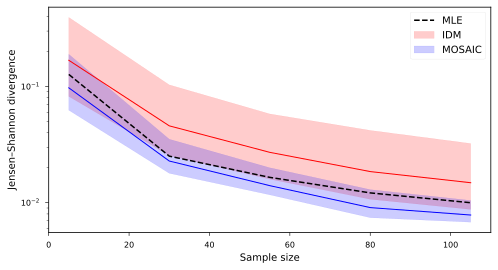

In [17]:
# Plot 
fig, ax = plt.subplots(1, 1)

ax.plot(df_mean["size"], df_mean["mle"], "--", linewidth=1.5, color="black", label="MLE")
ax.fill_between(df_mean["size"], df_mean["idm_min"], df_mean["idm_max"], color="red", alpha=.2, label="IDM")
ax.plot(df_mean["size"], df_mean["idm_mean"], color="red")
ax.fill_between(df_mean["size"], df_mean["mos_min"], df_mean["mos_max"], color="blue", alpha=.2, label="MOSAIC")
ax.plot(df_mean["size"], df_mean["mos_mean"], color="blue")

# Set logarithmic axis
ax.set_yscale('log')

ax.set_xlabel("Sample size")
ax.set_ylabel("Jensen–Shannon divergence")
# ax.title(res_path)

ax.legend(loc="upper right")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Save figure
fig.savefig(f"{res_path}.svg", dpi=1200, bbox_inches="tight", transparent=False)

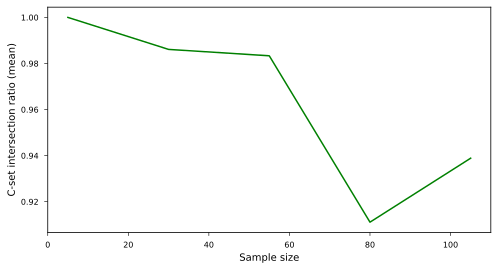

In [18]:
# Plot 
fig, ax = plt.subplots(1, 1)

ax.plot(df_mean["size"], df_mean["intersection_frac"], "-", linewidth=1.5, color="green")

ax.set_xlabel("Sample size")
ax.set_ylabel("C-set intersection ratio (mean)")
# ax.title(res_path)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Save figure
fig.savefig(f"{res_path}_intersection.svg", dpi=1200, bbox_inches="tight", transparent=False)